# Cardiovascular Disease Prediction
ML mini-project — Common Project Model (Phase 1)

Dataset: Cardiovascular Disease Dataset (Healthcare)

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import joblib

## 2. Load dataset

In [2]:
df = pd.read_csv('data/cardio_data.csv')
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,41,2,178.0,74.5,105,72,1,1,0,0,1,1
1,54,2,160.0,49.5,103,58,1,1,0,0,1,0
2,63,1,160.0,55.7,111,72,3,1,0,0,1,0
3,49,1,160.0,59.4,100,66,1,1,0,0,0,0
4,45,1,168.0,60.8,99,65,1,1,0,0,1,0


In [3]:
df.shape

(8000, 12)

## 3. Basic exploration

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          8000 non-null   int64  
 1   gender       8000 non-null   int64  
 2   height       7960 non-null   float64
 3   weight       8000 non-null   float64
 4   ap_hi        8000 non-null   int64  
 5   ap_lo        8000 non-null   int64  
 6   cholesterol  8000 non-null   int64  
 7   gluc         8000 non-null   int64  
 8   smoke        8000 non-null   int64  
 9   alco         8000 non-null   int64  
 10  active       8000 non-null   int64  
 11  cardio       8000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 750.1 KB


In [5]:
df.isnull().sum()

age             0
gender          0
height         40
weight          0
ap_hi           0
ap_lo           0
cholesterol     0
gluc            0
smoke           0
alco            0
active          0
cardio          0
dtype: int64

In [6]:
df['cardio'].value_counts()

cardio
1    4000
0    4000
Name: count, dtype: int64

## 4. Data cleaning & pre-processing

In [7]:
# fill the few missing height values with median
df['height'] = df['height'].fillna(df['height'].median())

# remove unrealistic blood pressure outliers
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 220)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 160)]

df.shape

(7985, 12)

In [8]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000,7985.000000
mean,49.698936,1.495304,166.484283,66.497796,109.309706,71.120601,1.493175,1.417408,0.180088,0.114339,0.804258,0.499812
std,8.676396,0.500009,8.431130,11.548847,10.096746,7.683843,0.720606,0.698174,0.384285,0.318243,0.396796,0.500031
min,35.000000,1.000000,134.000000,40.000000,75.000000,44.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,160.000000,58.300000,102.000000,66.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50.000000,1.000000,166.000000,66.300000,109.000000,71.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,57.000000,2.000000,172.000000,74.300000,116.000000,76.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,195.000000,105.700000,154.000000,103.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 5. EDA

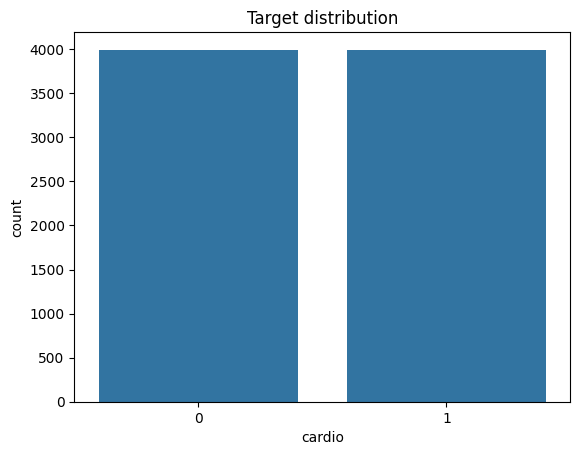

In [9]:
sns.countplot(x='cardio', data=df)
plt.title('Target distribution')
plt.show()

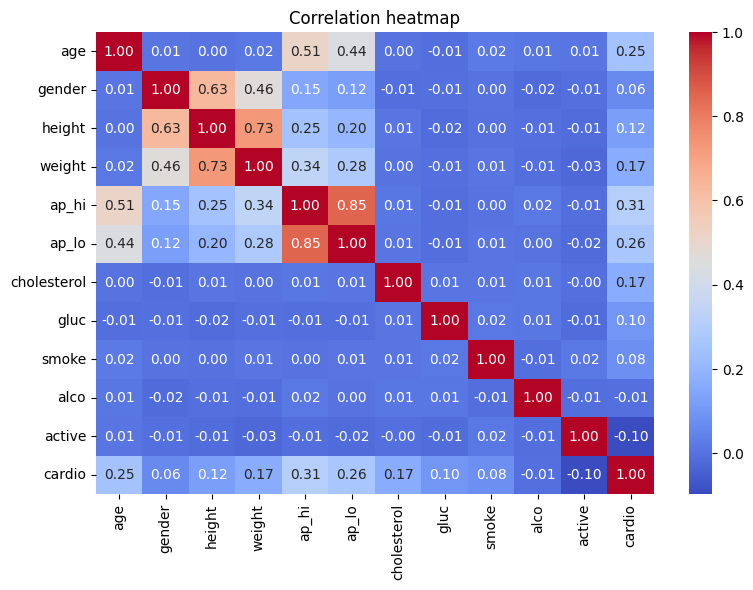

In [10]:
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

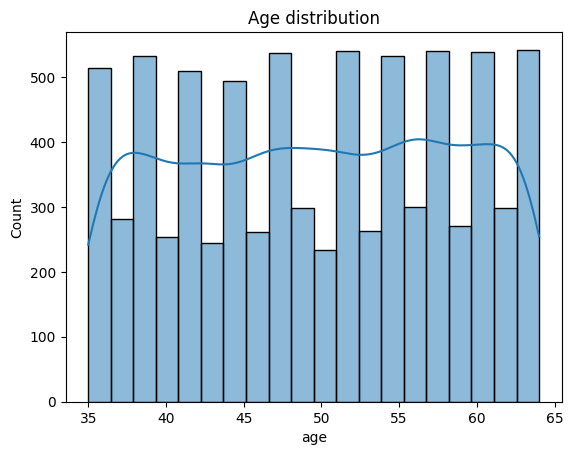

In [11]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age distribution')
plt.show()

## 6. Train / test split + feature scaling

In [12]:
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Logistic Regression (linear model)

In [13]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, log_pred))
print('F1 Score:', f1_score(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))

Accuracy: 0.6775203506574827
F1 Score: 0.6842427958307786
[[524 252]
 [263 558]]


## 8. Gradient Boosting Classifier

In [14]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

gb_pred = gb_model.predict(X_test_scaled)
gb_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print('Accuracy:', accuracy_score(y_test, gb_pred))
print('F1 Score:', f1_score(y_test, gb_pred))
print('ROC AUC:', roc_auc_score(y_test, gb_proba))

Accuracy: 0.667501565435191
F1 Score: 0.6728280961182994
ROC AUC: 0.7175229478759872


In [15]:
cv_scores = cross_val_score(gb_model, X_train_scaled, y_train, cv=5)
print('5-fold CV accuracy:', cv_scores.mean())

5-fold CV accuracy: 0.654820876884031


## 9. AdaBoost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# AdaBoost with Decision Tree stumps (depth=1) as base estimators
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train_scaled, y_train)

ada_pred  = ada_model.predict(X_test_scaled)
ada_proba = ada_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, ada_pred))
print("F1 Score:", f1_score(y_test, ada_pred))
print("ROC AUC: ", roc_auc_score(y_test, ada_proba))
print()
print(classification_report(y_test, ada_pred))
print(confusion_matrix(y_test, ada_pred))

In [ ]:
# RSS (Residual Sum of Squares) for AdaBoost
# For a classifier, RSS measures the sum of squared differences
# between predicted probabilities and true labels
ada_rss  = float(np.sum((ada_proba  - y_test.values) ** 2))
gb_rss   = float(np.sum((gb_proba   - y_test.values) ** 2))
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]
log_rss  = float(np.sum((log_proba  - y_test.values) ** 2))

print(f"AdaBoost   RSS: {ada_rss:.2f}")
print(f"Grad Boost RSS: {gb_rss:.2f}")
print(f"Logistic   RSS: {log_rss:.2f}")
print()
print("Lower RSS = better calibration of predicted probabilities.")

## 10. Compare models

In [ ]:
results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Gradient Boosting', 'AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, ada_pred)
    ],
    'F1 Score': [
        f1_score(y_test, log_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, ada_pred)
    ],
    'ROC AUC':  [
        roc_auc_score(y_test, log_proba),
        roc_auc_score(y_test, gb_proba),
        roc_auc_score(y_test, ada_proba)
    ],
    'RSS':      [log_rss, gb_rss, ada_rss]
})
results.round(4)

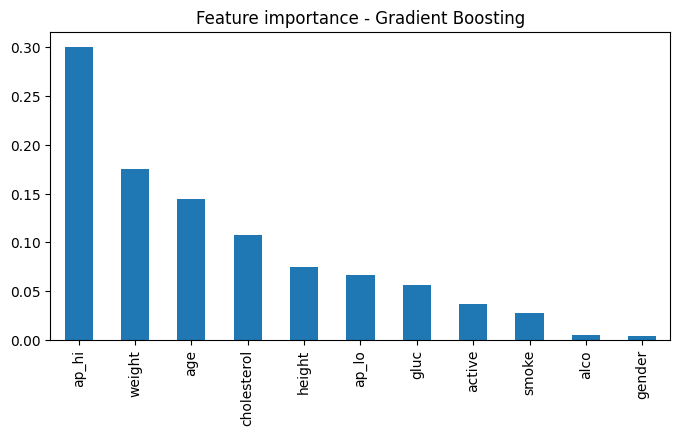

In [17]:
importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(8,4))
plt.title('Feature importance - Gradient Boosting')
plt.show()

## 11. Save the model

Gradient Boosting performed better, so that is the one we ship to the web app.

In [18]:
joblib.dump(gb_model, 'model/cardio_model.pkl')
joblib.dump(log_model, 'model/logistic_model.pkl')
joblib.dump(ada_model, 'model/adaboost_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/feature_names.pkl')

print('All 3 models and preprocessors saved successfully!')


model saved!
